Data scaled successfully!


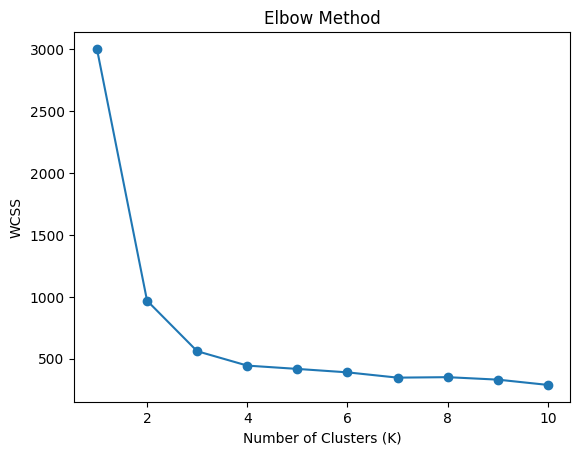

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  
Explained Variance Ratio: [0.83560354 0.05568764]
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


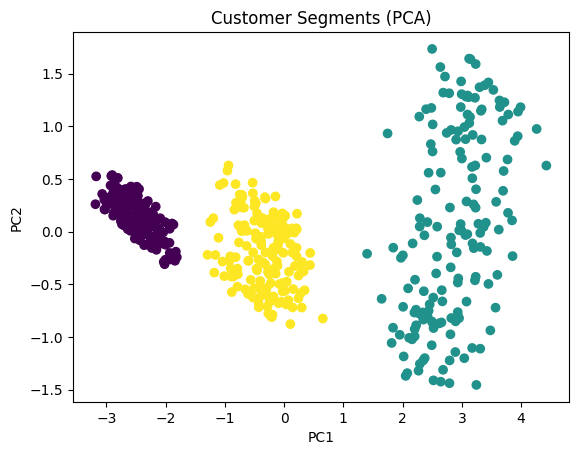

In [3]:
# 1. Data Preparation

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv(r"C:\Users\yasmi\OneDrive\Documents\ml-assessment-yasminbano-khan\data\q2_customers.csv")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Data scaled successfully!")

# 2. Choosing K — Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# 3. K-Means Clustering

# Choose K (example: 3 — replace with your value)
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['cluster'] = clusters

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print(centroids)

# 4. Dimensionality Reduction with PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

print(loadings)

# 5. Cluster Visualisation

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.title("Customer Segments (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

1.  Scaling is important before K-Means because it ensures that all features contribute equally to the clustering process.
2. The elbow point is observed at K = 3. After this point, the decrease in WCSS becomes less significant, indicating an optimal number of clusters.
3. PC1 captures the most important variation in the data, mainly influenced by features such as annual_spend, basket_size, age, and number of categories purchased.
4. PC2 captures secondary variation, influenced by features such as days_since_last_visit and visits_per_month, representing customer recency and activity level.